# Seasonal Agriculture Performance Analysis

## Major Project – VOIS AICTE 2026–2027

### Objective
To analyze agricultural data across different seasons and identify meaningful patterns, trends, relationships, and variations in agricultural performance.

### Tools and Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook / Google Colab

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [7]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
df.shape

(4000, 28)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [10]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [11]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [14]:
df['Season'].unique()

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

In [15]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [16]:
df['Crop'].unique()

array(['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli',
       'Groundnut', 'Sugarcane'], dtype=object)

In [17]:
df['Irrigation_Method'].unique()

array(['Drip', 'Flood', 'Rainfed', 'Sprinkler'], dtype=object)

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C',
       'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
       'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [19]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [20]:
df_clean = df.copy()


In [21]:
df_clean['Rainfall_mm'] = df_clean['Rainfall_mm'].fillna(
    df_clean['Rainfall_mm'].median()
)

In [22]:
df_clean['Soil_Moisture_pct'] = df_clean['Soil_Moisture_pct'].fillna(
    df_clean['Soil_Moisture_pct'].median()
)

In [23]:
df_clean['Yield_Tonnes_Ha'] = df_clean['Yield_Tonnes_Ha'].fillna(
    df_clean['Yield_Tonnes_Ha'].median()
)

In [24]:
df_clean.isnull().sum().sum()

np.int64(0)

In [25]:
df_clean.duplicated().sum()

np.int64(0)

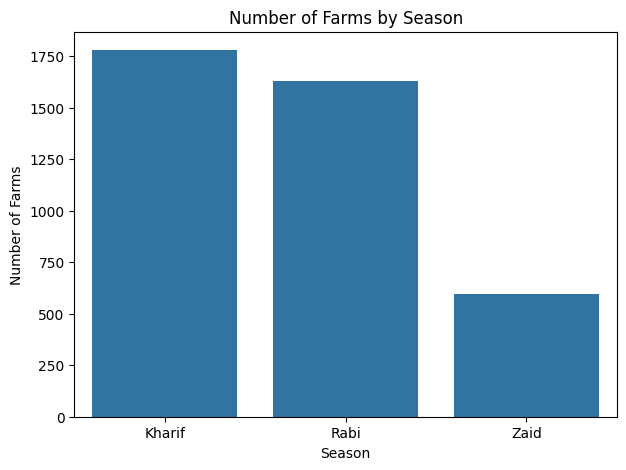

In [26]:
#EDA

plt.figure(figsize=(7,5))

sns.countplot(data=df_clean, x='Season')

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

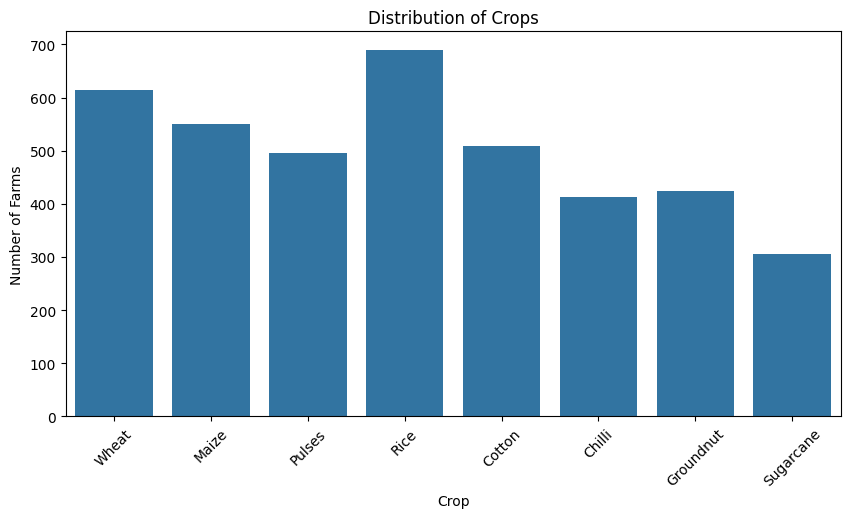

In [27]:
#crop distribution
plt.figure(figsize=(10,5))

sns.countplot(data=df_clean, x='Crop')

plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')

plt.xticks(rotation=45)

plt.show()

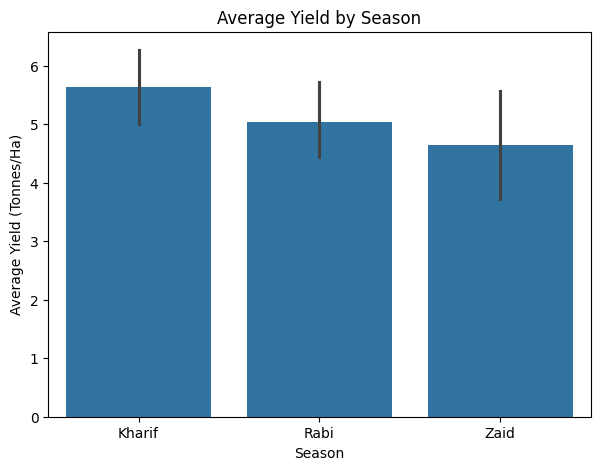

In [28]:
#avarage yeild by season
season_yield = df_clean.groupby('Season')['Yield_Tonnes_Ha'].mean()

season_yield

plt.figure(figsize=(7,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

In [29]:
df_clean.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


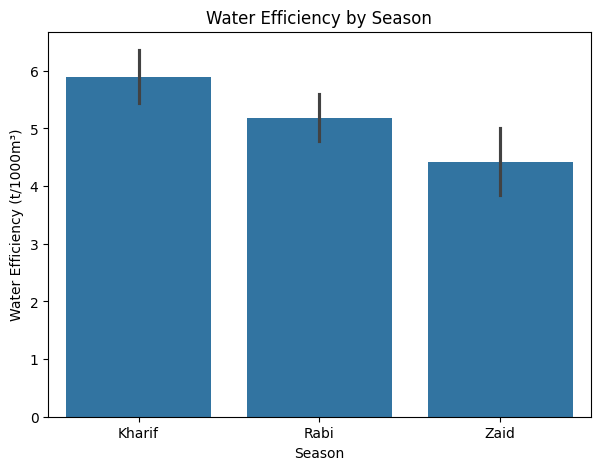

In [30]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    estimator='mean'
)

plt.title('Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (t/1000m³)')

plt.show()


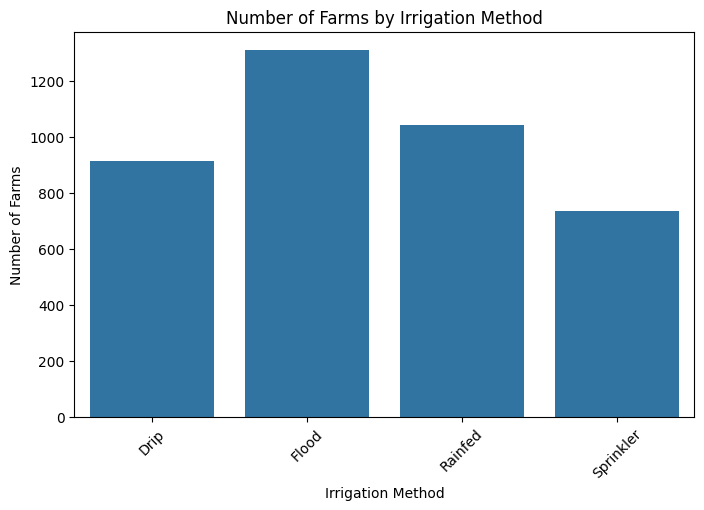

In [31]:
# EDA - Irrigation Method Distribution

plt.figure(figsize=(8,5))

sns.countplot(data=df_clean, x='Irrigation_Method')

plt.title('Number of Farms by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)

plt.show()

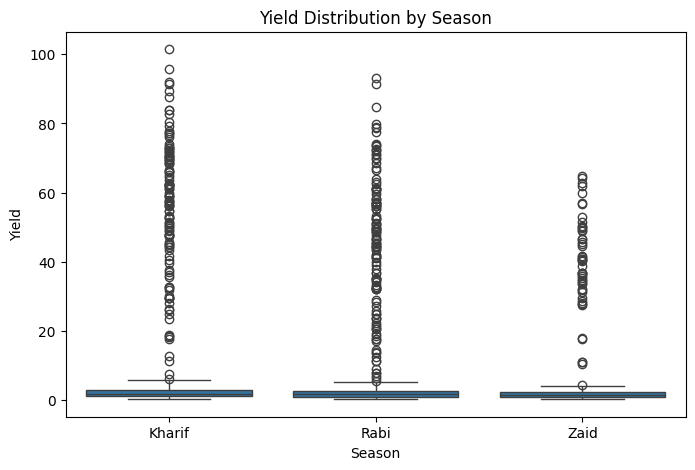

In [34]:
# EDA - Season-wise Yield Analysis

plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha')

plt.title('Yield Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Yield')

plt.show()

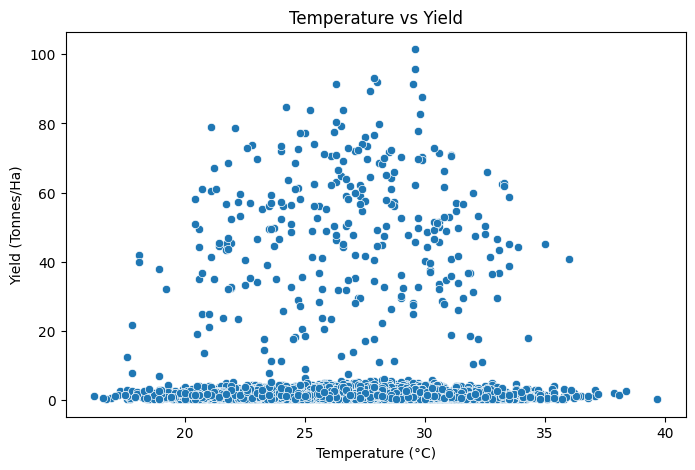

In [36]:
# EDA - Temperature vs Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha'
)

plt.title('Temperature vs Yield')
plt.xlabel('Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

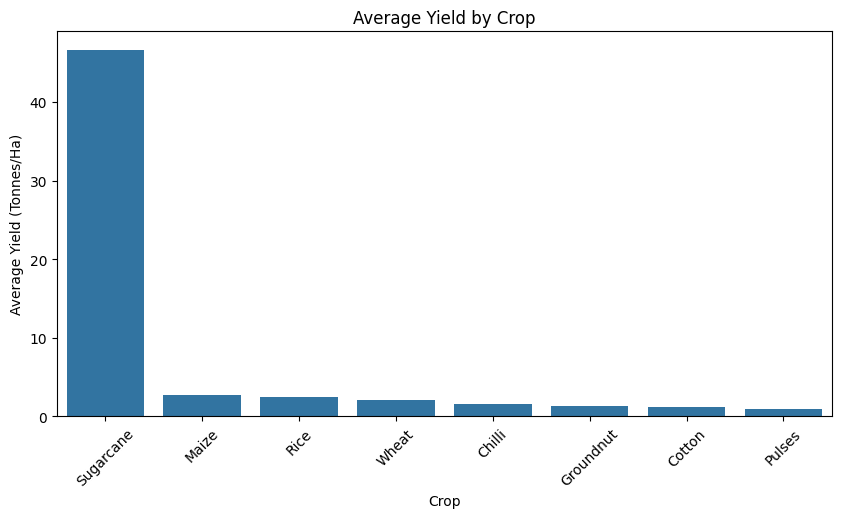

In [37]:
# EDA - Average Yield by Crop

avg_yield_crop = df_clean.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=avg_yield_crop.index,
    y=avg_yield_crop.values
)

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)

plt.show()

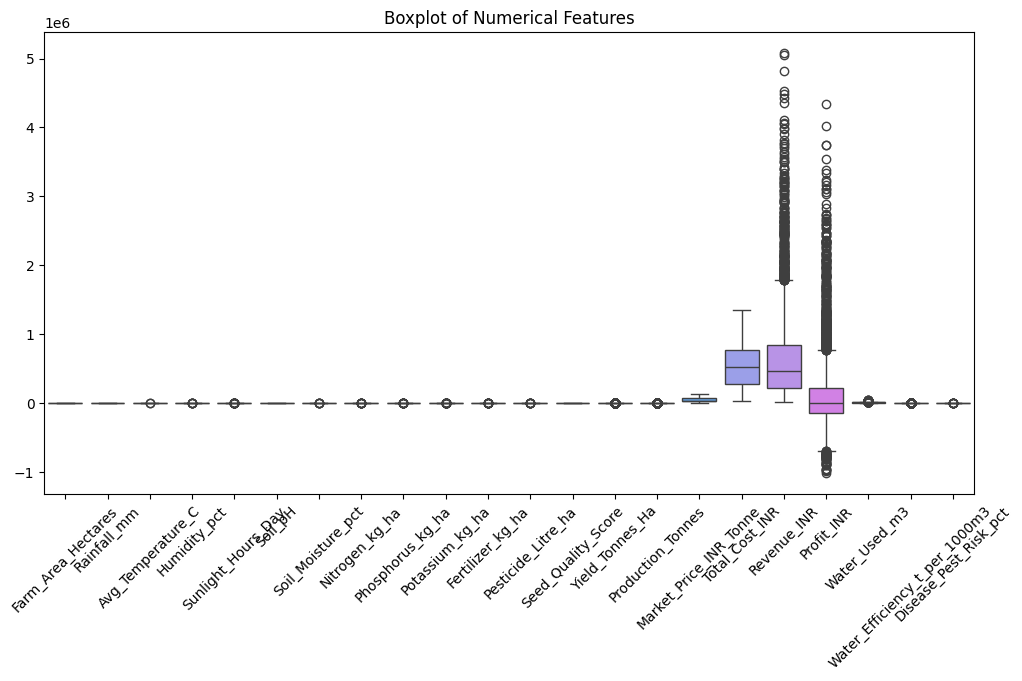

In [38]:
# EDA - Outlier Detection

numerical_cols = df_clean.select_dtypes(include='number').columns

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_clean[numerical_cols])

plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=45)

plt.show()

In [39]:
# EDA Summary

print("EDA completed successfully.")
print("The dataset was analyzed based on season, crop, irrigation method,")
print("numerical feature distributions, and their relationship with yield.")
print("Correlation analysis and outlier detection were also performed.")

EDA completed successfully.
The dataset was analyzed based on season, crop, irrigation method,
numerical feature distributions, and their relationship with yield.
Correlation analysis and outlier detection were also performed.


In [40]:
# Final dataset check

print("Shape:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())

print("\nMissing Values:")
print(df_clean.isnull().sum())

Shape: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Missing Values:
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha            

In [41]:
# Remove ID and potential data leakage columns

X = df_clean.drop([
    'Yield_Tonnes_Ha',
    'Farm_ID',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3'
], axis=1)

y = df_clean['Yield_Tonnes_Ha']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4000, 22)
Target shape: (4000,)


In [42]:
# Separate features and target

X = df_clean.drop('Yield_Tonnes_Ha', axis=1)
y = df_clean['Yield_Tonnes_Ha']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4000, 27)
Target shape: (4000,)


In [43]:
# Identify categorical and numerical columns

categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include='number').columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']
Numerical columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3200, 27)
Testing data: (800, 27)


In [46]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (3200, 3254)
Processed testing data: (800, 3254)


In [47]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_processed, y_train)

y_pred_lr = lr_model.predict(X_test_processed)

In [48]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²   :", r2_lr)

print("\nRandom Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²   :", r2_rf)

Linear Regression
MAE : 1.9909997648556879
RMSE: 3.8395380066888247
R²   : 0.9235364411987943

Random Forest
MAE : 0.50109925
RMSE: 1.7820311774559388
R²   : 0.9835287271537179


In [50]:
# Model Comparison

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.991000,3.839538,0.923536
1,Random Forest,0.501099,1.782031,0.983529


In [51]:
# Select best model based on R² score

best_model_name = results.loc[results['R2 Score'].idxmax(), 'Model']

print("Best Model:", best_model_name)

Best Model: Random Forest


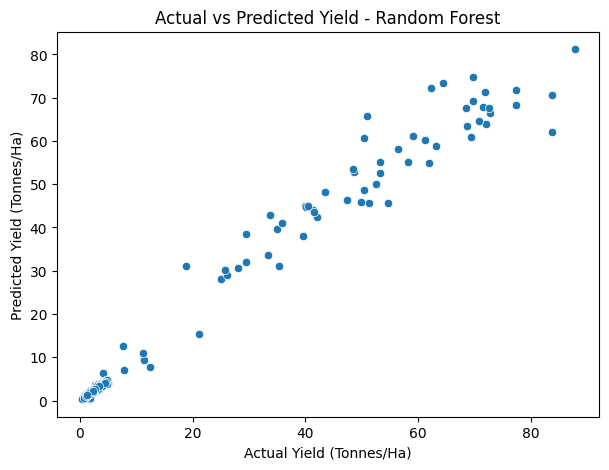

In [52]:
# Actual vs Predicted Yield

plt.figure(figsize=(7,5))

sns.scatterplot(x=y_test, y=y_pred_rf)

plt.xlabel('Actual Yield (Tonnes/Ha)')
plt.ylabel('Predicted Yield (Tonnes/Ha)')
plt.title('Actual vs Predicted Yield - Random Forest')

plt.show()

In [53]:
# Sample Predictions

prediction_df = pd.DataFrame({
    'Actual Yield': y_test.values,
    'Predicted Yield': y_pred_rf
})

prediction_df.head(10)

,Actual Yield,Predicted Yield
0,1.74,1.8226
1,0.94,0.9970
2,1.17,1.2348
3,0.88,1.0600
4,1.07,1.2216
5,1.00,1.0193
6,1.14,1.3000
7,0.52,0.5171
8,3.08,3.2824
9,0.47,0.5678


In [54]:
import joblib

# Save the trained model and preprocessing pipeline

joblib.dump(rf_model, 'agriculture_yield_model.pkl')
joblib.dump(preprocessor, 'agriculture_preprocessor.pkl')

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.
